In [1]:
!pip install hmmlearn scikit-learn numpy pandas matplotlib seaborn scipy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
#  Importing libraries
import os, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from hmmlearn import hmm
import hmmlearn

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print(" All libraries imported successfully")
print(f"   numpy      : {np.__version__}")
print(f"   pandas     : {pd.__version__}")
print(f"   hmmlearn   : {hmmlearn.__version__}")

 All libraries imported successfully
   numpy      : 2.2.6
   pandas     : 2.3.3
   hmmlearn   : 0.3.3


In [7]:
DATA_DIR   = r"C:\Users\PC\Desktop\summative\HMM-Human-Activity-Recognition\data\raw"
PROC_DIR   = r"C:\Users\PC\Desktop\summative\HMM-Human-Activity-Recognition\data\processed"
FIG_DIR    = r"C:\Users\PC\Desktop\summative\HMM-Human-Activity-Recognition\figures"
MODEL_DIR  = r"C:\Users\PC\Desktop\summative\HMM-Human-Activity-Recognition\models"

for d in [PROC_DIR, FIG_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

ACTIVITIES  = ["standing", "walking", "jumping", "still"]
SAMPLE_RATE = 100
WINDOW_SEC  = 1.0
STEP_SEC    = 0.5
WINDOW_SIZE = int(WINDOW_SEC * SAMPLE_RATE)
STEP_SIZE   = int(STEP_SEC   * SAMPLE_RATE)
N_STATES    = 4

print(f"Window size  : {WINDOW_SIZE} samples ({WINDOW_SEC}s)")
print(f"Step size    : {STEP_SIZE} samples  ({STEP_SEC}s overlap)")
print(f"Hidden states: {N_STATES}")
print(f"Data dir     : {DATA_DIR}")

Window size  : 100 samples (1.0s)
Step size    : 50 samples  (0.5s overlap)
Hidden states: 4
Data dir     : C:\Users\PC\Desktop\summative\HMM-Human-Activity-Recognition\data\raw


In [8]:
def load_activity_data(activity):
    """Load and merge Accelerometer + Gyroscope CSVs for a given activity."""
    act_dir   = os.path.join(DATA_DIR, activity)
    
    # Only grab calibrated files
    acc_files = sorted([f for f in os.listdir(act_dir) if 'Accelerometer' in f and 'Uncalibrated' not in f])
    gyr_files = sorted([f for f in os.listdir(act_dir) if 'Gyroscope'     in f and 'Uncalibrated' not in f])

    frames = []
    for af, gf in zip(acc_files, gyr_files):
        # Load and rename axes for consistency
        acc = pd.read_csv(os.path.join(act_dir, af)).rename(columns={'x':'acc_x','y':'acc_y','z':'acc_z'})
        gyr = pd.read_csv(os.path.join(act_dir, gf)).rename(columns={'x':'gyro_x','y':'gyro_y','z':'gyro_z'})

        # Keep only relevant columns and drop any missing values
        acc = acc[['seconds_elapsed','acc_x','acc_y','acc_z']].dropna()
        gyr = gyr[['seconds_elapsed','gyro_x','gyro_y','gyro_z']].dropna()

        # Merge accelerometer and gyroscope on nearest timestamp (tolerance = 20ms)
        merged = pd.merge_asof(
            acc.sort_values('seconds_elapsed'),
            gyr.sort_values('seconds_elapsed'),
            on='seconds_elapsed', direction='nearest', tolerance=0.02
        ).dropna()

        merged['activity'] = activity
        frames.append(merged)

    return pd.concat(frames, ignore_index=True)

# Load all four activities
raw_data = {}
for act in ACTIVITIES:
    raw_data[act] = load_activity_data(act)
    print(f"{act:>10} | {len(raw_data[act]):>6} rows | duration: {raw_data[act]['seconds_elapsed'].max():.1f}s")

all_raw = pd.concat(raw_data.values(), ignore_index=True)
print(f"\n{'TOTAL':>10} | {len(all_raw):>6} rows")

  standing |   8938 rows | duration: 91.0s
   walking |   8390 rows | duration: 91.0s
   jumping |  11842 rows | duration: 91.0s
     still |   8817 rows | duration: 90.7s

     TOTAL |  37987 rows


In [9]:
# Basic statistics per activity 

print("  EXPLORATORY DATA ANALYSIS Summary Statistics")

for act in ACTIVITIES:
    df = raw_data[act]
    print(f"  Activity : {act.upper()}")
    print(f"  Rows     : {len(df)}  |  Duration: {df['seconds_elapsed'].max():.1f}s")
    print(f"  Sampling : ~{1 / df['seconds_elapsed'].diff().median():.0f} Hz")
    print(df[['acc_x','acc_y','acc_z','gyro_x','gyro_y','gyro_z']].describe().round(3).to_string())
print("  Class distribution across all windows:")
print(all_raw['activity'].value_counts().to_string())

  EXPLORATORY DATA ANALYSIS Summary Statistics
  Activity : STANDING
  Rows     : 8938  |  Duration: 91.0s
  Sampling : ~100 Hz
          acc_x     acc_y     acc_z    gyro_x    gyro_y    gyro_z
count  8938.000  8938.000  8938.000  8938.000  8938.000  8938.000
mean      0.019    -0.003     0.001     0.001     0.003    -0.004
std       0.086     0.050     0.145     0.030     0.029     0.035
min      -0.610    -0.300    -1.056    -0.346    -0.325    -0.214
25%      -0.030    -0.034    -0.085    -0.012    -0.009    -0.022
50%       0.019    -0.002     0.000     0.002     0.004    -0.003
75%       0.068     0.028     0.086     0.017     0.017     0.014
max       0.675     0.315     1.189     0.134     0.144     0.227
  Activity : WALKING
  Rows     : 8390  |  Duration: 91.0s
  Sampling : ~100 Hz
          acc_x     acc_y     acc_z    gyro_x    gyro_y    gyro_z
count  8390.000  8390.000  8390.000  8390.000  8390.000  8390.000
mean      0.076    -0.146     0.039     0.015     0.019     0.010


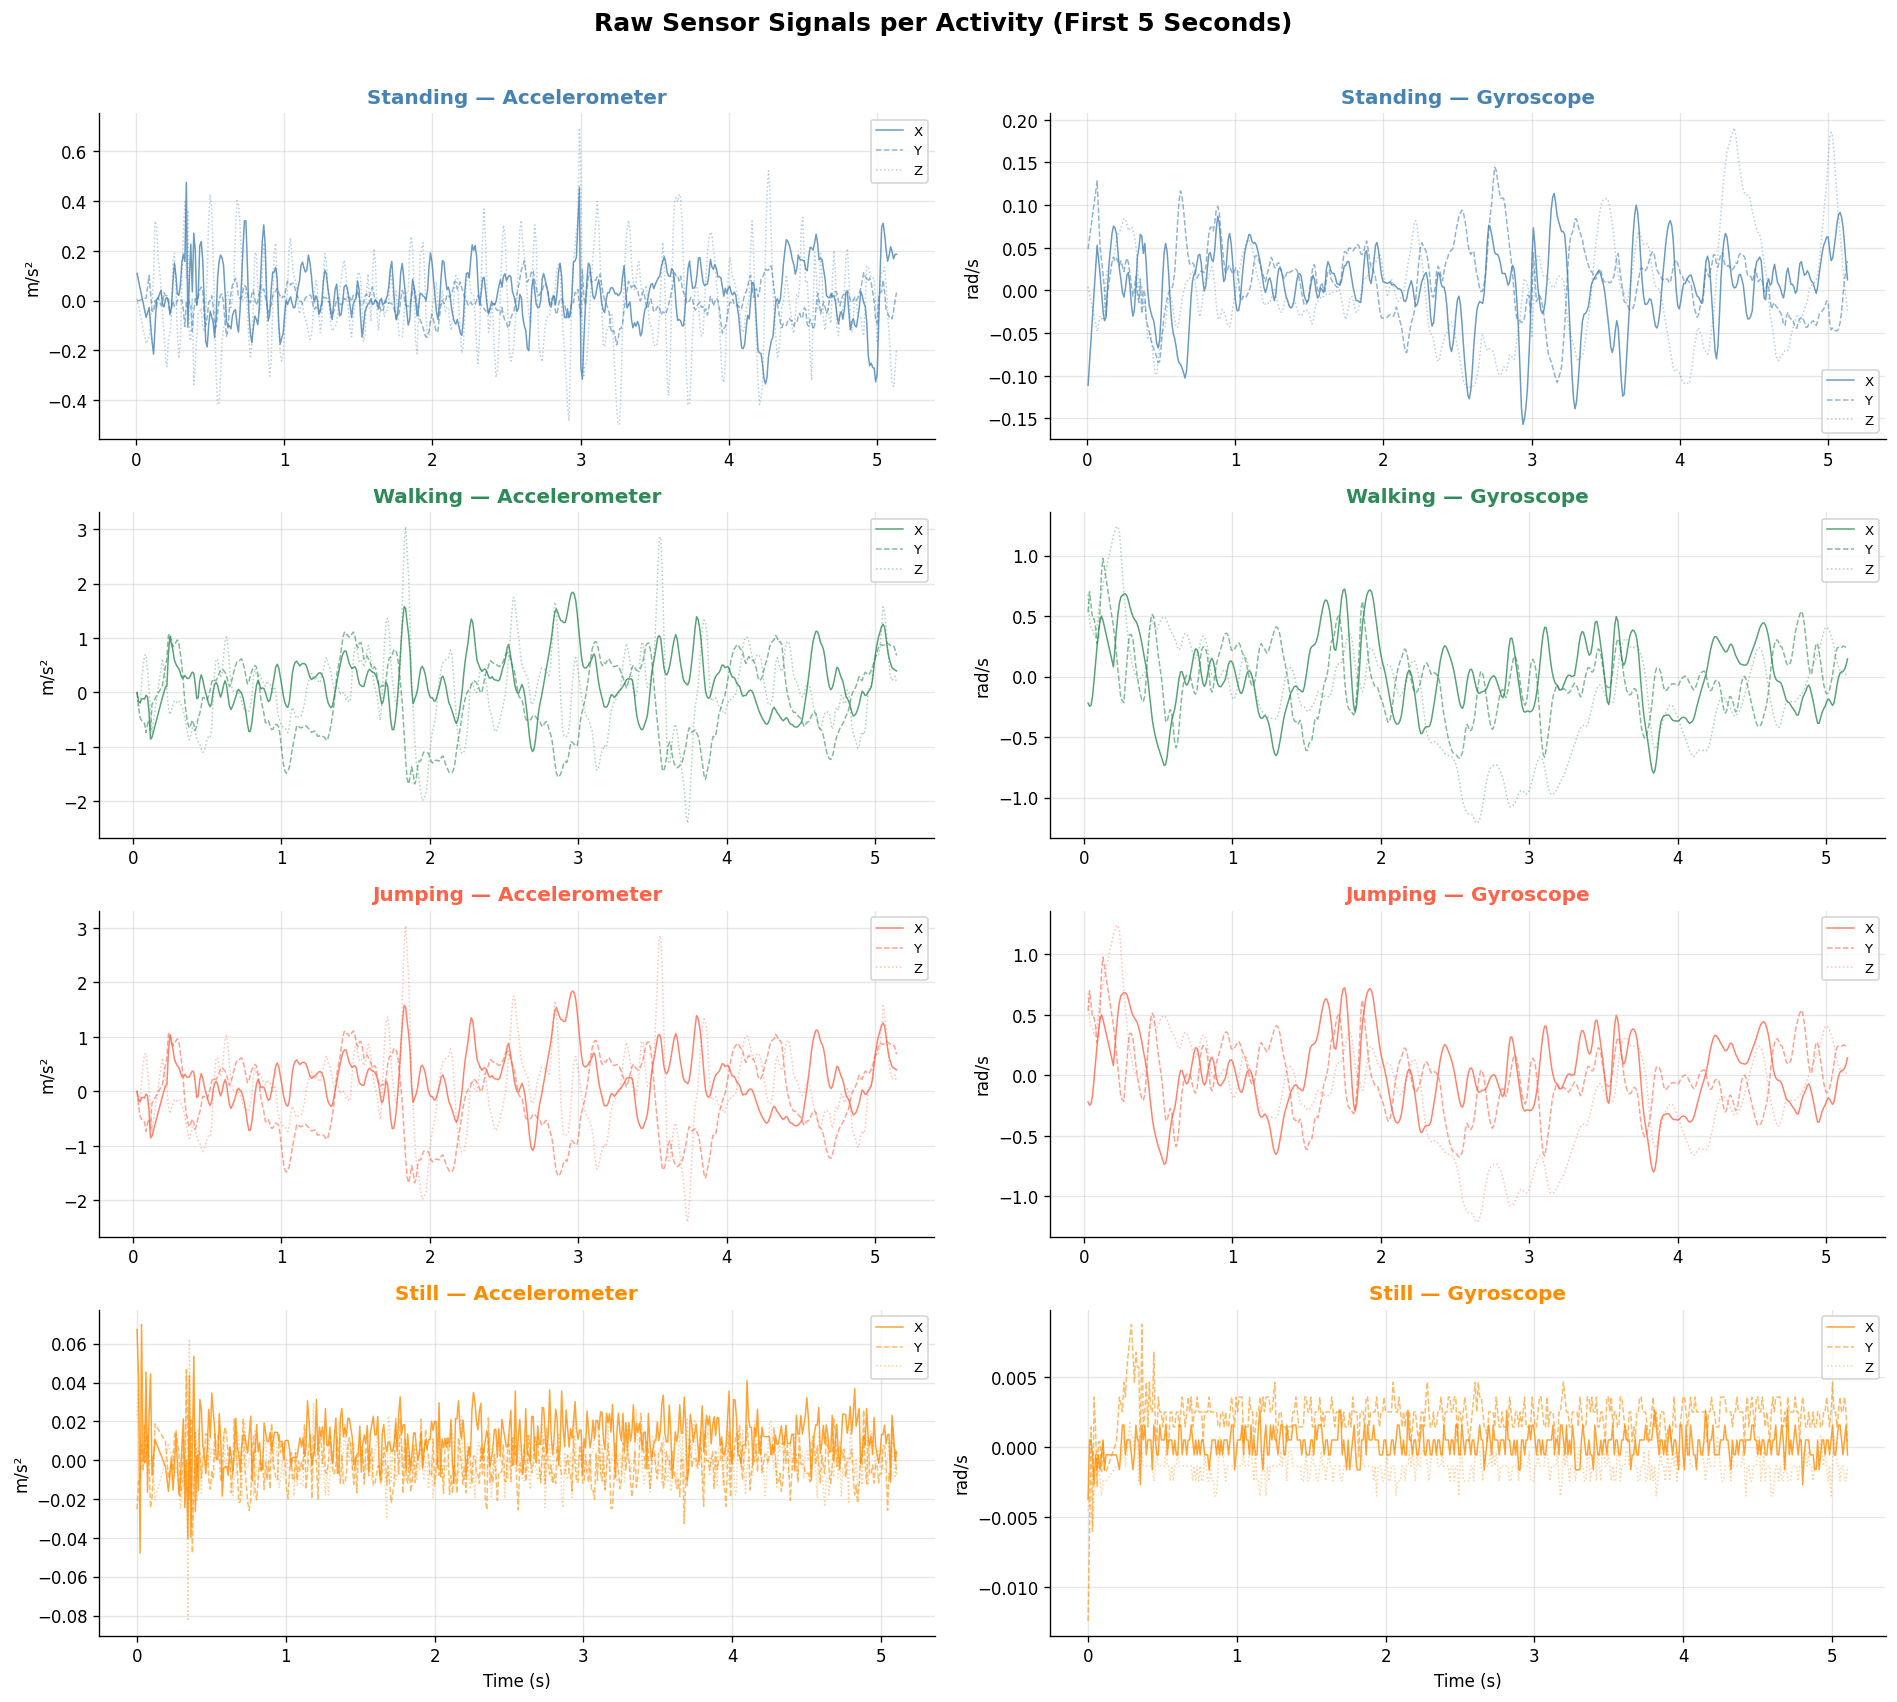

 Saved: figures/raw_signals.png


In [10]:
# Raw Signal Plots
colors = {'standing':'steelblue', 'walking':'seagreen', 'jumping':'tomato', 'still':'darkorange'}

fig, axes = plt.subplots(4, 2, figsize=(16, 14))
fig.suptitle('Raw Sensor Signals per Activity (First 5 Seconds)', fontsize=15, fontweight='bold', y=1.01)

for i, act in enumerate(ACTIVITIES):
    df = raw_data[act].iloc[:500]
    t  = df['seconds_elapsed'].values
    c  = colors[act]

    # Accelerometer
    axes[i, 0].plot(t, df['acc_x'], alpha=0.8, linewidth=0.9, label='X', color=c)
    axes[i, 0].plot(t, df['acc_y'], alpha=0.6, linewidth=0.9, label='Y', color=c, linestyle='--')
    axes[i, 0].plot(t, df['acc_z'], alpha=0.4, linewidth=0.9, label='Z', color=c, linestyle=':')
    axes[i, 0].set_title(f'{act.capitalize()} — Accelerometer', fontweight='bold', color=c)
    axes[i, 0].set_ylabel('m/s²')
    axes[i, 0].legend(fontsize=8)
    axes[i, 0].grid(alpha=0.3)

    # Gyroscope
    axes[i, 1].plot(t, df['gyro_x'], alpha=0.8, linewidth=0.9, label='X', color=c)
    axes[i, 1].plot(t, df['gyro_y'], alpha=0.6, linewidth=0.9, label='Y', color=c, linestyle='--')
    axes[i, 1].plot(t, df['gyro_z'], alpha=0.4, linewidth=0.9, label='Z', color=c, linestyle=':')
    axes[i, 1].set_title(f'{act.capitalize()} — Gyroscope', fontweight='bold', color=c)
    axes[i, 1].set_ylabel('rad/s')
    axes[i, 1].legend(fontsize=8)
    axes[i, 1].grid(alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel('Time (s)')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'raw_signals.png'), bbox_inches='tight')
plt.show()
print(" Saved: figures/raw_signals.png")

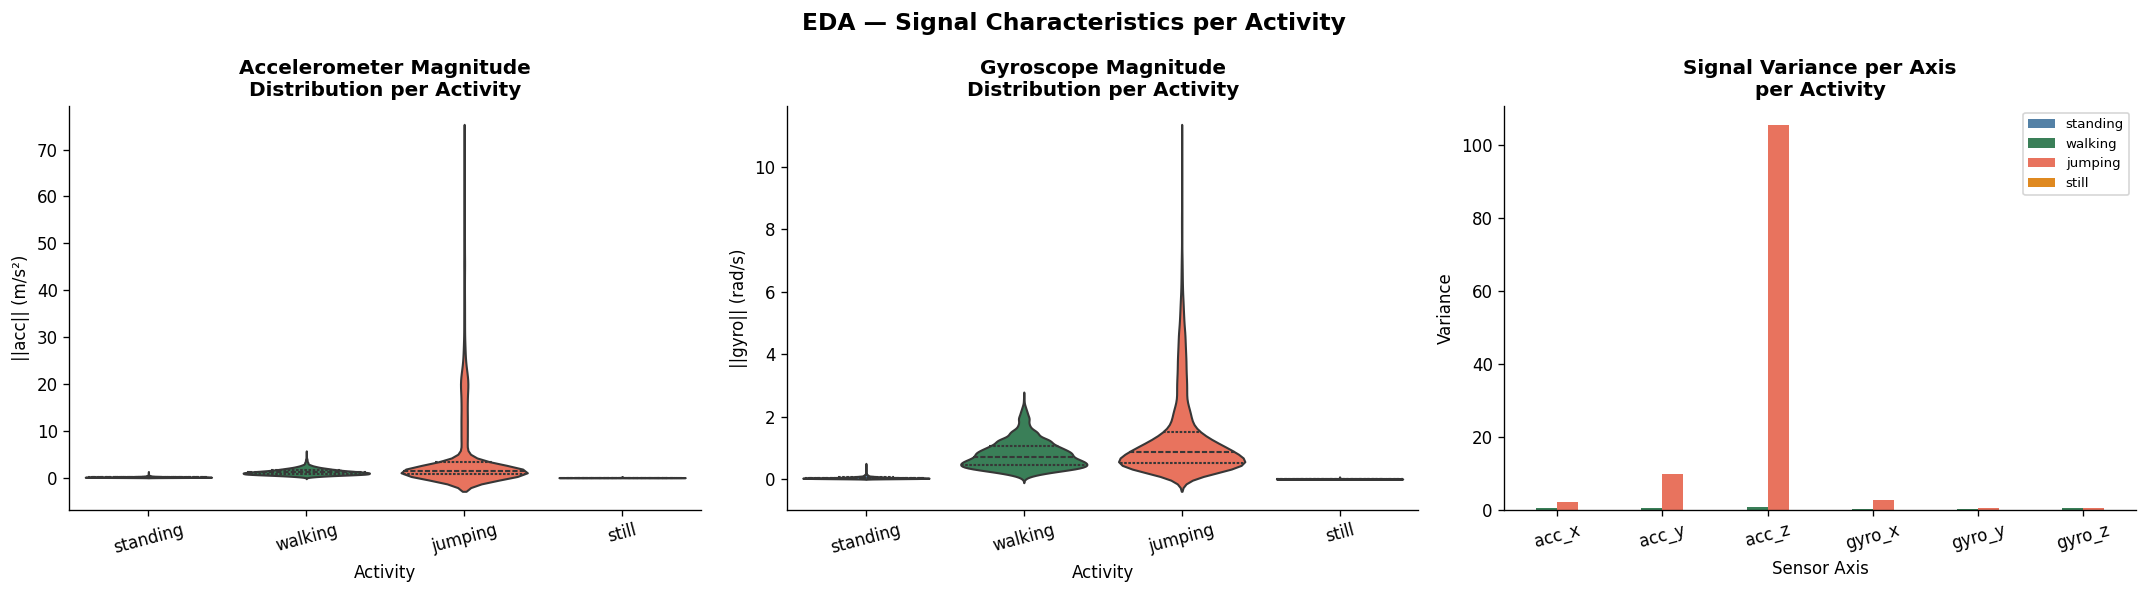

 Saved: figures/eda_signal_characteristics.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EDA — Signal Characteristics per Activity', fontsize=14, fontweight='bold')

# Accelerometer magnitude distribution 
all_raw['acc_magnitude'] = np.sqrt(all_raw['acc_x']**2 + all_raw['acc_y']**2 + all_raw['acc_z']**2)

sns.violinplot(data=all_raw, x='activity', y='acc_magnitude',
               palette=colors, ax=axes[0], inner='quartile', order=ACTIVITIES)
axes[0].set_title('Accelerometer Magnitude\nDistribution per Activity', fontweight='bold')
axes[0].set_xlabel('Activity')
axes[0].set_ylabel('||acc|| (m/s²)')
axes[0].tick_params(axis='x', rotation=15)

# Gyroscope magnitude distribution
all_raw['gyro_magnitude'] = np.sqrt(all_raw['gyro_x']**2 + all_raw['gyro_y']**2 + all_raw['gyro_z']**2)

sns.violinplot(data=all_raw, x='activity', y='gyro_magnitude',
               palette=colors, ax=axes[1], inner='quartile', order=ACTIVITIES)
axes[1].set_title('Gyroscope Magnitude\nDistribution per Activity', fontweight='bold')
axes[1].set_xlabel('Activity')
axes[1].set_ylabel('||gyro|| (rad/s)')
axes[1].tick_params(axis='x', rotation=15)

# Variance per axis per activity
var_data = []
for act in ACTIVITIES:
    df = raw_data[act]
    for col in ['acc_x','acc_y','acc_z','gyro_x','gyro_y','gyro_z']:
        var_data.append({'Activity': act, 'Axis': col, 'Variance': df[col].var()})

var_df = pd.DataFrame(var_data)
sns.barplot(data=var_df, x='Axis', y='Variance', hue='Activity',
            palette=colors, ax=axes[2], order=['acc_x','acc_y','acc_z','gyro_x','gyro_y','gyro_z'])
axes[2].set_title('Signal Variance per Axis\nper Activity', fontweight='bold')
axes[2].set_xlabel('Sensor Axis')
axes[2].set_ylabel('Variance')
axes[2].tick_params(axis='x', rotation=15)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_signal_characteristics.png'), bbox_inches='tight')
plt.show()
print(" Saved: figures/eda_signal_characteristics.png")

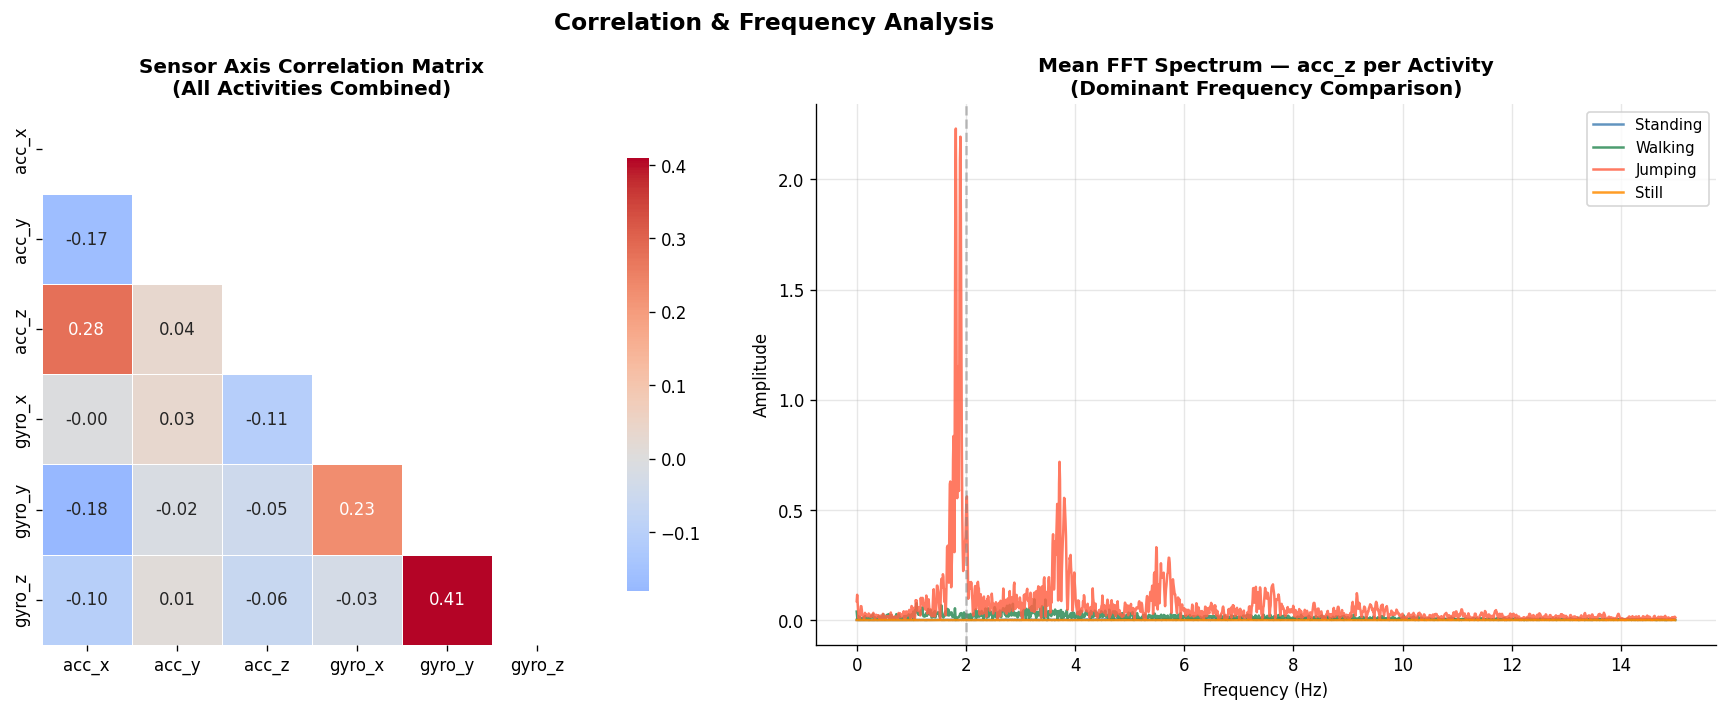

 Saved: figures/eda_correlation_fft.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Correlation & Frequency Analysis', fontsize=14, fontweight='bold')

#  Correlation heatmap across all sensor axes 
sensor_cols = ['acc_x','acc_y','acc_z','gyro_x','gyro_y','gyro_z']
corr_matrix = all_raw[sensor_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[0], mask=mask,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
axes[0].set_title('Sensor Axis Correlation Matrix\n(All Activities Combined)', fontweight='bold')

# Mean FFT spectrum per activity 
axes[1].set_title('Mean FFT Spectrum — acc_z per Activity\n(Dominant Frequency Comparison)', fontweight='bold')

for act in ACTIVITIES:
    df      = raw_data[act]
    sig     = df['acc_z'].values
    N       = len(sig)
    freqs   = fftfreq(N, d=1.0/SAMPLE_RATE)[:N//2]
    mag     = np.abs(fft(sig))[:N//2] / N
    # Smooth and plot only 0–15 Hz for clarity
    mask_f  = freqs <= 15
    axes[1].plot(freqs[mask_f], mag[mask_f], label=act.capitalize(),
                 color=colors[act], linewidth=1.5, alpha=0.85)

axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Amplitude')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].axvline(x=2, color='grey', linestyle='--', alpha=0.5, label='2 Hz (walking cadence)')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_correlation_fft.png'), bbox_inches='tight')
plt.show()
print(" Saved: figures/eda_correlation_fft.png")

In [14]:
def extract_features(window):
    """Extract 26 time-domain and frequency-domain features from a single window."""
    feats = {}
    sensor_cols = ['acc_x','acc_y','acc_z','gyro_x','gyro_y','gyro_z']

    # Time-domain: mean, variance, std, RMS per axis
    for col in sensor_cols:
        sig = window[col].values
        feats[f'{col}_mean'] = np.mean(sig)
        feats[f'{col}_var']  = np.var(sig)
        feats[f'{col}_std']  = np.std(sig)
        feats[f'{col}_rms']  = np.sqrt(np.mean(sig**2))

    # Signal Magnitude Area — total movement energy across all axes
    feats['acc_sma']  = np.sum(np.abs(window['acc_x'])  + np.abs(window['acc_y'])  + np.abs(window['acc_z']))  / len(window)
    feats['gyro_sma'] = np.sum(np.abs(window['gyro_x']) + np.abs(window['gyro_y']) + np.abs(window['gyro_z'])) / len(window)

    # Correlation between accelerometer axes — captures movement coordination
    feats['acc_corr_xy'] = np.corrcoef(window['acc_x'], window['acc_y'])[0,1]
    feats['acc_corr_xz'] = np.corrcoef(window['acc_x'], window['acc_z'])[0,1]

    # Frequency-domain: dominant frequency, spectral energy, spectral entropy
    for col in ['acc_x','acc_y','acc_z']:
        sig      = window[col].values
        N        = len(sig)
        freqs    = fftfreq(N, d=1.0/SAMPLE_RATE)
        mag      = np.abs(fft(sig))[:N//2]
        pos_f    = freqs[:N//2]

        # Dominant frequency — walking ~2 Hz, jumping ~1-2 Hz, still ~0 Hz
        feats[f'{col}_dom_freq']     = pos_f[np.argmax(mag)]

        # Spectral energy — total power in the frequency spectrum
        feats[f'{col}_spec_energy']  = np.sum(mag**2) / N

        # Spectral entropy — regularity of motion (low = periodic, high = random)
        mag_norm = mag / (np.sum(mag) + 1e-10)
        feats[f'{col}_spec_entropy'] = -np.sum(mag_norm * np.log(mag_norm + 1e-10))

    return feats


def window_and_extract(df):
    """Slide window over signal and extract features from each window."""
    records = []
    for start in range(0, len(df) - WINDOW_SIZE + 1, STEP_SIZE):
        w    = df.iloc[start:start + WINDOW_SIZE]
        feat = extract_features(w)
        feat['activity'] = w['activity'].iloc[0]
        records.append(feat)
    return pd.DataFrame(records)


# Extract features for all activities
feat_frames = []
for act in ACTIVITIES:
    fdf = window_and_extract(raw_data[act])
    feat_frames.append(fdf)
    print(f"{act:>10} | {len(fdf):>4} windows extracted")

features_df = pd.concat(feat_frames, ignore_index=True)
feature_cols = [c for c in features_df.columns if c != 'activity']

print(f"\n  Total windows : {len(features_df)}")
print(f"  Feature count : {len(feature_cols)}")
features_df.to_csv(os.path.join(PROC_DIR, 'features.csv'), index=False)
print(" Saved: data/processed/features.csv")

  standing |  177 windows extracted
   walking |  166 windows extracted
   jumping |  235 windows extracted
     still |  175 windows extracted

  Total windows : 753
  Feature count : 37
 Saved: data/processed/features.csv


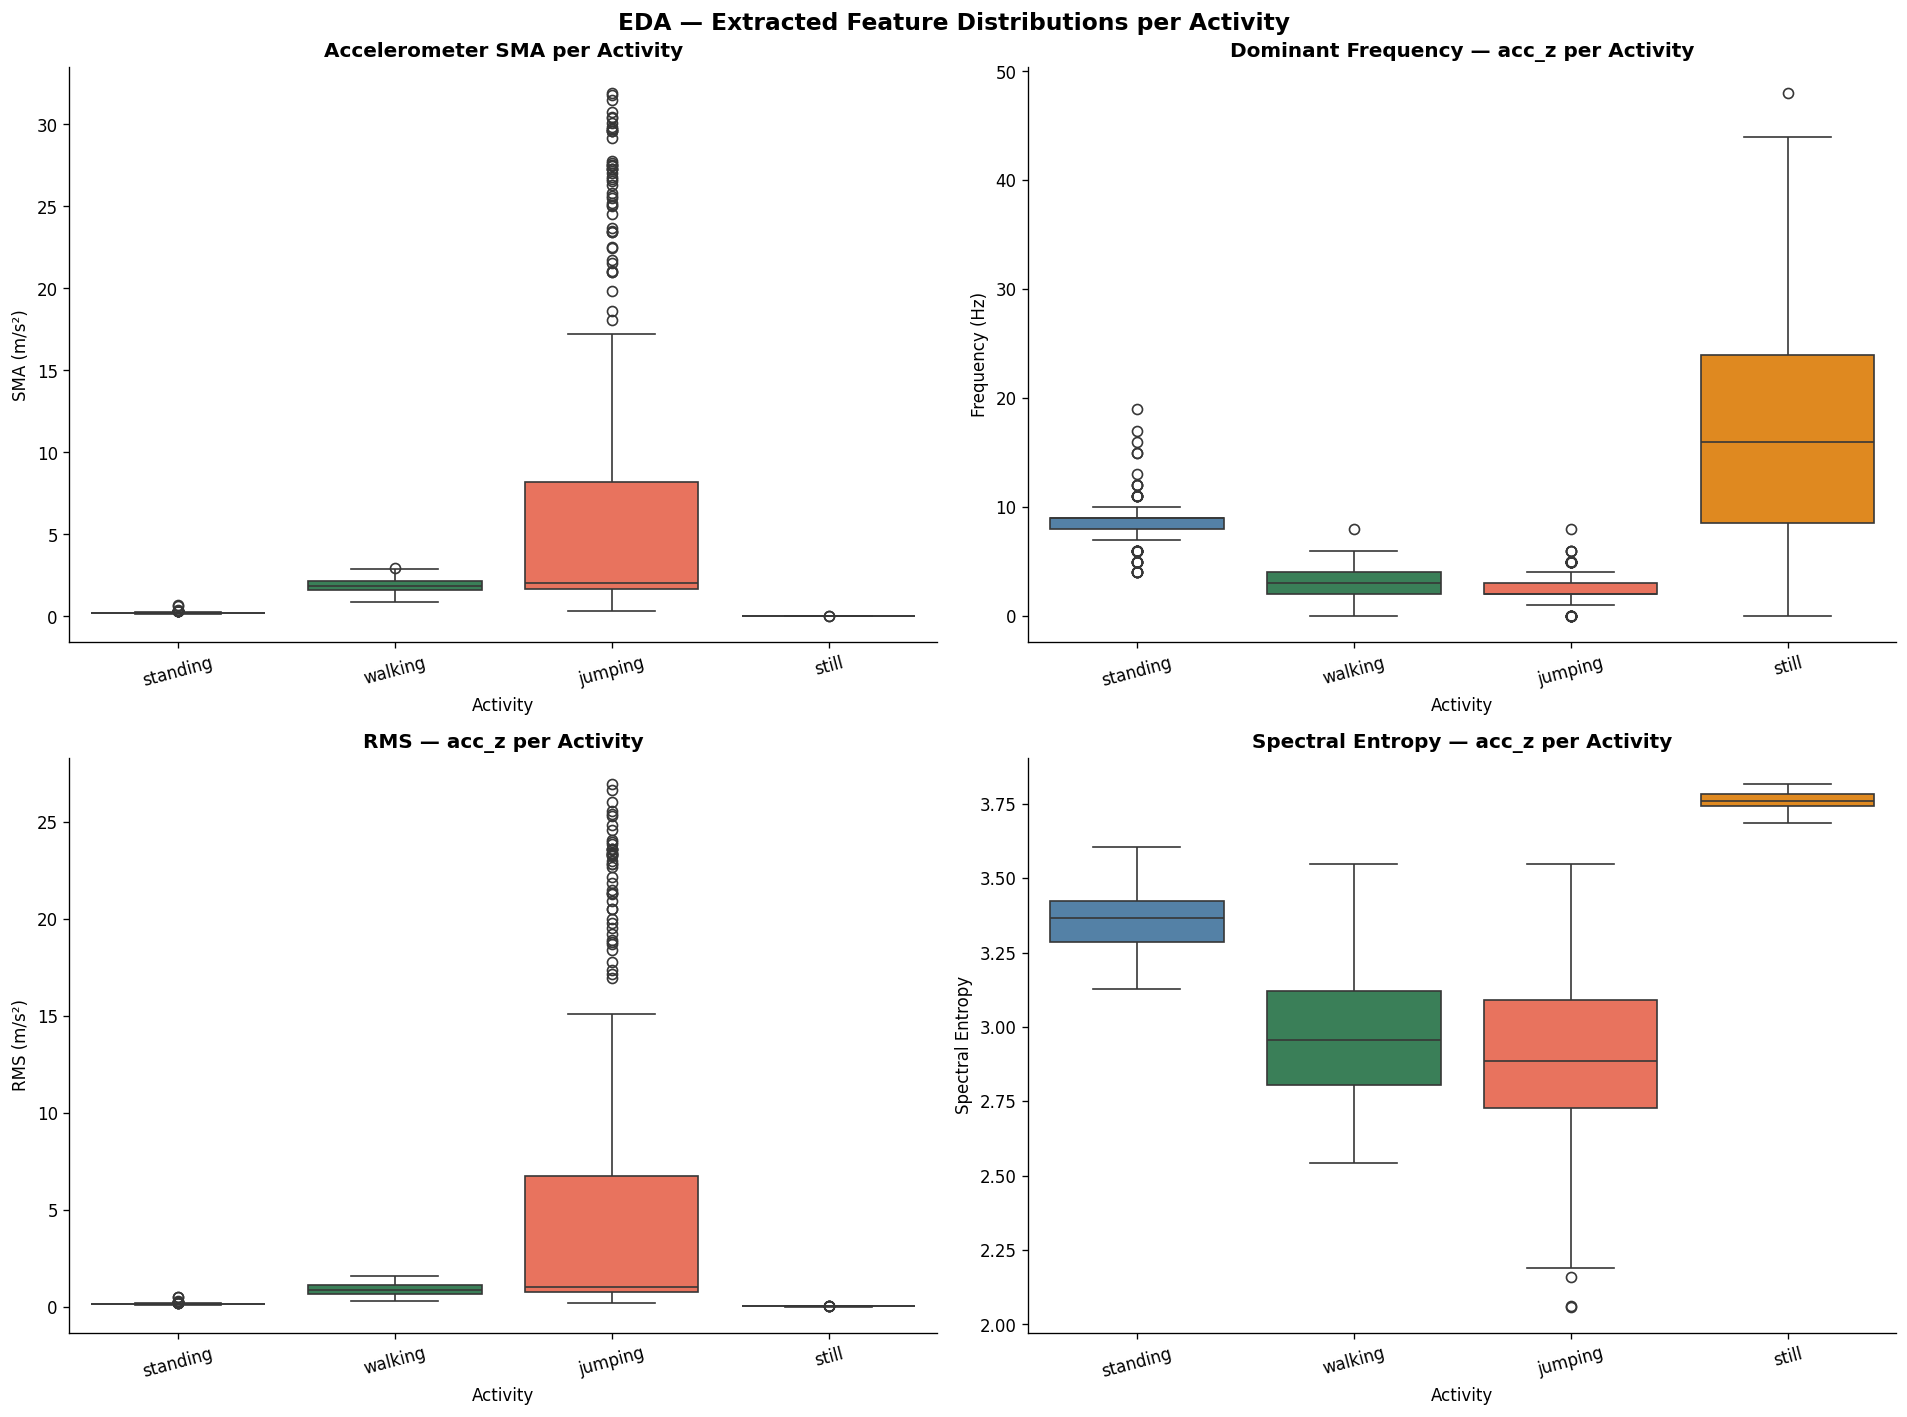

 Saved: figures/eda_feature_distributions.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('EDA — Extracted Feature Distributions per Activity', fontsize=14, fontweight='bold')

#  SMA distribution per activity
sns.boxplot(data=features_df, x='activity', y='acc_sma',
            palette=colors, ax=axes[0,0], order=ACTIVITIES)
axes[0,0].set_title('Accelerometer SMA per Activity', fontweight='bold')
axes[0,0].set_xlabel('Activity')
axes[0,0].set_ylabel('SMA (m/s²)')
axes[0,0].tick_params(axis='x', rotation=15)

# Dominant frequency distribution
sns.boxplot(data=features_df, x='activity', y='acc_z_dom_freq',
            palette=colors, ax=axes[0,1], order=ACTIVITIES)
axes[0,1].set_title('Dominant Frequency — acc_z per Activity', fontweight='bold')
axes[0,1].set_xlabel('Activity')
axes[0,1].set_ylabel('Frequency (Hz)')
axes[0,1].tick_params(axis='x', rotation=15)

#  RMS of acc_z per activity 
sns.boxplot(data=features_df, x='activity', y='acc_z_rms',
            palette=colors, ax=axes[1,0], order=ACTIVITIES)
axes[1,0].set_title('RMS — acc_z per Activity', fontweight='bold')
axes[1,0].set_xlabel('Activity')
axes[1,0].set_ylabel('RMS (m/s²)')
axes[1,0].tick_params(axis='x', rotation=15)

# Spectral entropy of acc_z 
sns.boxplot(data=features_df, x='activity', y='acc_z_spec_entropy',
            palette=colors, ax=axes[1,1], order=ACTIVITIES)
axes[1,1].set_title('Spectral Entropy — acc_z per Activity', fontweight='bold')
axes[1,1].set_xlabel('Activity')
axes[1,1].set_ylabel('Spectral Entropy')
axes[1,1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_feature_distributions.png'), bbox_inches='tight')
plt.show()
print(" Saved: figures/eda_feature_distributions.png")

In [16]:
# Separate features from labels
X_raw = features_df[feature_cols].values
y     = features_df['activity'].values

scaler = StandardScaler()
X      = scaler.fit_transform(X_raw)

# Encode string activity labels to integers
le          = LabelEncoder()
y_enc       = le.fit_transform(y)
class_names = le.classes_

print("Label encoding:")
for cls, enc in zip(class_names, le.transform(class_names)):
    print(f"  {cls:>10} → {enc}")

print(f"\nFeature matrix shape : {X.shape}")
print(f"Min after scaling    : {X.min():.3f}")
print(f"Max after scaling    : {X.max():.3f}")
print(f"Mean after scaling   : {X.mean():.6f}  (should be ≈ 0)")

Label encoding:
     jumping → 0
    standing → 1
       still → 2
     walking → 3

Feature matrix shape : (753, 37)
Min after scaling    : -6.698
Max after scaling    : 12.452
Mean after scaling   : 0.000000  (should be ≈ 0)


In [18]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

print("Train/Test Split Summary")
print(f"  Total windows : {len(X)}")
print(f"  Train windows : {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Test  windows : {len(X_test)}  ({len(X_test)/len(X)*100:.0f}%)")
print(f"\n  {'Activity':<12} {'Train':>6} {'Test':>6}")
print(f"  {'-'*26}")
for i, cls in enumerate(class_names):
    tr = np.sum(y_train == i)
    te = np.sum(y_test  == i)
    print(f"  {cls:<12} {tr:>6} {te:>6}")

Train/Test Split Summary
  Total windows : 753
  Train windows : 602 (80%)
  Test  windows : 151  (20%)

  Activity      Train   Test
  --------------------------
  jumping         188     47
  standing        141     36
  still           140     35
  walking         133     33
